# GRUPO 06: Caso Electricidad - Entregable

## Análisis de Detección de Fraude Eléctrico con Técnicas Avanzadas

Este notebook implementa técnicas adicionales de preprocesamiento, balanceo de datos, detección de outliers y modelamiento para la detección de fraude eléctrico.

### Objetivos:
1. **Interpolación**: Implementar 2 métodos adicionales de interpolación
2. **Balanceo de datos**: Aplicar 2 técnicas diferentes de balanceo
3. **Detección de outliers**: Usar 2 técnicas adicionales de outliers
4. **Extracción de características**: Utilizar Random Forest como método de IA
5. **Modelamiento**: Aplicar modelos con hiperparámetros específicos


In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import math
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef
from scipy import interpolate
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
%matplotlib inline
plt.style.use('seaborn-v0_8')

# Variables generales
ruta_model = "Caso Electricidad/Model/"
ruta_df = "Caso Electricidad/Datasets/"
ruta_metrics = "Caso Electricidad/Metrics/"
semilla = 111

print("Librerías importadas correctamente")


Librerías importadas correctamente


In [2]:
# Carga de datos originales
df_original = pd.read_csv(f'{ruta_df}data.csv')
print(f"Datos originales cargados: {df_original.shape}")
print(f"Distribución de FLAG: \n{df_original['FLAG'].value_counts()}")
df_original.head()


Datos originales cargados: (42372, 1036)
Distribución de FLAG: 
FLAG
0    38757
1     3615
Name: count, dtype: int64


,CONS_NO,FLAG,2014/1/1,2014/1/10,2014/1/11,2014/1/12,2014/1/13,2014/1/14,2014/1/15,2014/1/16,...,2016/9/28,2016/9/29,2016/9/3,2016/9/30,2016/9/4,2016/9/5,2016/9/6,2016/9/7,2016/9/8,2016/9/9
0,0387DD8A07E07FDA6271170F86AD9151,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.12,9.96,16.92,7.60,27.22,18.05,26.47,18.75,17.84,14.92
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B32AC8CC6D5D805AC053557AB05F5343,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.50,9.99,11.78,18.59,26.80,18.57,14.59,12.82,19.37,15.92
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.9,3.42,3.81,4.58,3.56,4.25,3.86,3.53,...,17.77,10.37,15.32,13.51,12.23,14.68,16.35,18.14,18.41,17.31


## 1. Métodos de Interpolación Adicionales

### 1.1 Interpolación Spline Cúbica

La interpolación spline cúbica utiliza polinomios de tercer grado para crear una curva suave que pasa por todos los puntos de datos.


In [3]:
def spline_interpolation(df):
    """
    Aplica interpolación spline cúbica a los valores faltantes
    """
    df_spline = df.copy()
    
    # Obtener columnas de fechas (excluyendo CONS_NO, FLAG y Three_Sigma_Rule)
    date_columns = [col for col in df.columns if col not in ['CONS_NO', 'FLAG', 'Three_Sigma_Rule']]
    
    for idx, row in df_spline.iterrows():
        # Obtener valores de la serie temporal
        values = row[date_columns].values
        
        # Identificar valores no nulos
        valid_indices = ~pd.isna(values)
        
        if valid_indices.sum() > 3:  # Necesitamos al menos 4 puntos para spline cúbico
            # Crear índices para interpolación
            x_valid = np.where(valid_indices)[0]
            y_valid = values[valid_indices]
            
            # Crear spline cúbico
            try:
                cs = interpolate.CubicSpline(x_valid, y_valid, extrapolate=True)
                
                # Interpolar valores faltantes
                missing_indices = np.where(~valid_indices)[0]
                if len(missing_indices) > 0:
                    interpolated_values = cs(missing_indices)
                    # Asegurar valores no negativos
                    interpolated_values = np.maximum(interpolated_values, 0)
                    
                    # Asignar valores interpolados
                    for i, missing_idx in enumerate(missing_indices):
                        df_spline.iloc[idx, df_spline.columns.get_loc(date_columns[missing_idx])] = interpolated_values[i]
            except:
                # Si falla la interpolación spline, usar interpolación lineal como respaldo
                df_spline.iloc[idx, 2:-1] = df_spline.iloc[idx, 2:-1].interpolate(method='linear')
    
    return df_spline

# Aplicar interpolación spline
print("Aplicando interpolación Spline Cúbica...")
df_spline = spline_interpolation(df_original)
print(f"Interpolación completada. Valores NaN restantes: {df_spline.isnull().sum().sum()}")


Aplicando interpolación Spline Cúbica...
Interpolación completada. Valores NaN restantes: 6201


### 1.2 Interpolación por Promedio Móvil

La interpolación por promedio móvil utiliza la media de una ventana deslizante para estimar valores faltantes.


In [4]:
def moving_average_interpolation(df, window_size=7):
    """
    Aplica interpolación por promedio móvil a los valores faltantes
    """
    df_ma = df.copy()
    
    # Obtener columnas de fechas
    date_columns = [col for col in df.columns if col not in ['CONS_NO', 'FLAG', 'Three_Sigma_Rule']]
    
    for idx, row in df_ma.iterrows():
        # Obtener valores de la serie temporal
        values = row[date_columns].values.astype(float)
        
        # Identificar valores faltantes
        missing_indices = np.where(pd.isna(values))[0]
        
        for missing_idx in missing_indices:
            # Definir ventana alrededor del valor faltante
            start_idx = max(0, missing_idx - window_size // 2)
            end_idx = min(len(values), missing_idx + window_size // 2 + 1)
            
            # Obtener valores válidos en la ventana
            window_values = values[start_idx:end_idx]
            valid_window_values = window_values[~pd.isna(window_values)]
            
            if len(valid_window_values) > 0:
                # Usar promedio de valores válidos
                interpolated_value = np.mean(valid_window_values)
            else:
                # Si no hay valores válidos en la ventana, usar promedio global
                valid_values = values[~pd.isna(values)]
                if len(valid_values) > 0:
                    interpolated_value = np.mean(valid_values)
                else:
                    interpolated_value = 0
            
            # Asegurar valor no negativo
            interpolated_value = max(0, interpolated_value)
            
            # Asignar valor interpolado
            df_ma.iloc[idx, df_ma.columns.get_loc(date_columns[missing_idx])] = interpolated_value
    
    return df_ma

# Aplicar interpolación por promedio móvil
print("Aplicando interpolación por Promedio Móvil...")
df_moving_avg = moving_average_interpolation(df_original, window_size=7)
print(f"Interpolación completada. Valores NaN restantes: {df_moving_avg.isnull().sum().sum()}")


Aplicando interpolación por Promedio Móvil...
Interpolación completada. Valores NaN restantes: 0


## 2. Técnicas de Detección y Tratamiento de Outliers

### 2.1 Método de Rango Intercuartílico (IQR)

El método IQR identifica outliers como valores que están fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR].


In [6]:
def detect_outliers_iqr(df):
    """
    Detecta outliers usando el método IQR y los reemplaza con el límite superior
    """
    df_iqr = df.copy()
    
    # Obtener columnas de fechas (excluir columnas no numéricas)
    exclude_cols = ['CONS_NO', 'FLAG']
    if 'Three_Sigma_Rule' in df.columns:
        exclude_cols.append('Three_Sigma_Rule')
    
    date_columns = [col for col in df.columns if col not in exclude_cols]
    
    # Crear columna IQR_Outlier_Limit si no existe
    if 'IQR_Outlier_Limit' not in df_iqr.columns:
        df_iqr['IQR_Outlier_Limit'] = 0.0
    
    for idx, row in df_iqr.iterrows():
        # Obtener valores de la serie temporal
        values = row[date_columns].values.astype(float)
        
        # Calcular Q1, Q3 e IQR
        Q1 = np.percentile(values, 25)
        Q3 = np.percentile(values, 75)
        IQR = Q3 - Q1
        
        # Definir límites
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identificar outliers
        outliers_mask = (values < lower_bound) | (values > upper_bound)
        
        # Reemplazar outliers con el límite más cercano
        values_corrected = values.copy()
        values_corrected[values < lower_bound] = lower_bound
        values_corrected[values > upper_bound] = upper_bound
        
        # Asegurar valores no negativos
        values_corrected = np.maximum(values_corrected, 0)
        
        # Actualizar el DataFrame
        for i, col in enumerate(date_columns):
            df_iqr.iloc[idx, df_iqr.columns.get_loc(col)] = values_corrected[i]
        
        # Guardar el límite superior como referencia
        df_iqr.iloc[idx, df_iqr.columns.get_loc('IQR_Outlier_Limit')] = upper_bound
    
    return df_iqr

# Aplicar detección de outliers con IQR al dataset con interpolación spline
print("Aplicando detección de outliers con método IQR...")
df_spline_iqr = detect_outliers_iqr(df_spline)
print("Detección de outliers IQR completada.")


Aplicando detección de outliers con método IQR...
Detección de outliers IQR completada.


### 2.2 Método de Aislamiento por Bosque (Isolation Forest)

Isolation Forest es un algoritmo de detección de anomalías que aísla outliers construyendo árboles de decisión aleatorios.


In [7]:
from sklearn.ensemble import IsolationForest

def detect_outliers_isolation_forest(df, contamination=0.1):
    """
    Detecta outliers usando Isolation Forest y los reemplaza con la mediana
    """
    df_if = df.copy()
    
    # Obtener columnas de fechas (excluir columnas no numéricas)
    exclude_cols = ['CONS_NO', 'FLAG']
    if 'Three_Sigma_Rule' in df.columns:
        exclude_cols.append('Three_Sigma_Rule')
    if 'IQR_Outlier_Limit' in df.columns:
        exclude_cols.append('IQR_Outlier_Limit')
    
    date_columns = [col for col in df.columns if col not in exclude_cols]
    
    # Crear columna IF_Outlier_Limit si no existe
    if 'IF_Outlier_Limit' not in df_if.columns:
        df_if['IF_Outlier_Limit'] = 0.0
    
    for idx, row in df_if.iterrows():
        # Obtener valores de la serie temporal
        values = row[date_columns].values.astype(float).reshape(-1, 1)
        
        # Aplicar Isolation Forest
        iso_forest = IsolationForest(contamination=contamination, random_state=semilla)
        outliers = iso_forest.fit_predict(values)
        
        # Identificar outliers (etiquetados como -1)
        outlier_indices = np.where(outliers == -1)[0]
        
        if len(outlier_indices) > 0:
            # Calcular mediana de valores normales
            normal_values = values[outliers == 1].flatten()
            if len(normal_values) > 0:
                median_value = np.median(normal_values)
            else:
                median_value = np.median(values.flatten())
            
            # Reemplazar outliers con la mediana
            values_corrected = values.flatten().copy()
            values_corrected[outlier_indices] = median_value
            
            # Asegurar valores no negativos
            values_corrected = np.maximum(values_corrected, 0)
            
            # Actualizar el DataFrame
            for i, col in enumerate(date_columns):
                df_if.iloc[idx, df_if.columns.get_loc(col)] = values_corrected[i]
            
            # Guardar el valor máximo como referencia
            df_if.iloc[idx, df_if.columns.get_loc('IF_Outlier_Limit')] = np.max(values_corrected)
        else:
            # Si no hay outliers, mantener el valor máximo original
            df_if.iloc[idx, df_if.columns.get_loc('IF_Outlier_Limit')] = np.max(values.flatten())
    
    return df_if

# Aplicar detección de outliers con Isolation Forest al dataset con interpolación promedio móvil
print("Aplicando detección de outliers con Isolation Forest...")
df_ma_if = detect_outliers_isolation_forest(df_moving_avg, contamination=0.1)
print("Detección de outliers con Isolation Forest completada.")


Aplicando detección de outliers con Isolation Forest...
Detección de outliers con Isolation Forest completada.


## 3. Extracción de Características con Random Forest

### 3.1 Extracción de Características Estadísticas Tradicionales

Primero extraemos características estadísticas básicas de las series temporales.


In [8]:
def extract_statistical_features(df):
    """
    Extrae características estadísticas de las series temporales
    """
    df_features = df.copy()
    
    # Obtener columnas de fechas
    date_columns = [col for col in df.columns if col not in ['CONS_NO', 'FLAG', 'Three_Sigma_Rule']]
    
    # Extraer características estadísticas
    df_features['Sum'] = df_features[date_columns].sum(axis=1)
    df_features['Mean'] = df_features[date_columns].mean(axis=1)
    df_features['Median'] = df_features[date_columns].median(axis=1)
    df_features['Std'] = df_features[date_columns].std(axis=1)
    df_features['Var'] = df_features[date_columns].var(axis=1)
    df_features['Min'] = df_features[date_columns].min(axis=1)
    df_features['Max'] = df_features[date_columns].max(axis=1)
    df_features['Range'] = df_features['Max'] - df_features['Min']
    df_features['Q1'] = df_features[date_columns].quantile(0.25, axis=1)
    df_features['Q3'] = df_features[date_columns].quantile(0.75, axis=1)
    df_features['IQR'] = df_features['Q3'] - df_features['Q1']
    df_features['Skewness'] = df_features[date_columns].skew(axis=1)
    df_features['Kurtosis'] = df_features[date_columns].kurtosis(axis=1)
    
    # Características adicionales
    df_features['Zero_Count'] = (df_features[date_columns] == 0).sum(axis=1)
    df_features['Non_Zero_Count'] = (df_features[date_columns] != 0).sum(axis=1)
    df_features['Zero_Ratio'] = df_features['Zero_Count'] / len(date_columns)
    
    return df_features

# Extraer características de ambos datasets procesados
print("Extrayendo características estadísticas...")
df_spline_iqr_features = extract_statistical_features(df_spline_iqr)
df_ma_if_features = extract_statistical_features(df_ma_if)
print("Extracción de características estadísticas completada.")


Extrayendo características estadísticas...
Extracción de características estadísticas completada.


### 3.2 Extracción de Características con Random Forest

Utilizamos Random Forest para identificar las características más importantes y crear nuevas características basadas en la importancia de las variables.


In [9]:
def rf_feature_extraction(df, n_estimators=100, max_depth=10):
    """
    Utiliza Random Forest para extraer características importantes
    """
    # Obtener columnas de características estadísticas
    feature_columns = ['Sum', 'Mean', 'Median', 'Std', 'Var', 'Min', 'Max', 'Range', 
                      'Q1', 'Q3', 'IQR', 'Skewness', 'Kurtosis', 'Zero_Count', 
                      'Non_Zero_Count', 'Zero_Ratio']
    
    # Preparar datos
    X = df[feature_columns].fillna(0)
    y = df['FLAG']
    
    # Entrenar Random Forest
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=semilla,
        n_jobs=-1
    )
    
    rf.fit(X, y)
    
    # Obtener importancias de características
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Crear nuevas características basadas en importancia
    df_rf_features = df.copy()
    
    # Característica: Suma ponderada por importancia
    weighted_sum = 0
    for _, row in feature_importance.iterrows():
        feature_name = row['feature']
        importance = row['importance']
        weighted_sum += df[feature_name] * importance
    
    df_rf_features['RF_Weighted_Sum'] = weighted_sum
    
    # Característica: Score de anomalía basado en RF
    anomaly_scores = rf.predict_proba(X)[:, 1]  # Probabilidad de ser fraude
    df_rf_features['RF_Anomaly_Score'] = anomaly_scores
    
    # Característica: Combinación de top 3 características más importantes
    top_3_features = feature_importance.head(3)['feature'].tolist()
    df_rf_features['RF_Top3_Combined'] = df[top_3_features].mean(axis=1)
    
    return df_rf_features, feature_importance, rf

# Aplicar extracción de características con Random Forest
print("Aplicando extracción de características con Random Forest...")

# Para dataset con Spline + IQR
df_spline_iqr_rf, importance_spline, rf_spline = rf_feature_extraction(
    df_spline_iqr_features, n_estimators=100, max_depth=10
)

# Para dataset con Moving Average + Isolation Forest
df_ma_if_rf, importance_ma, rf_ma = rf_feature_extraction(
    df_ma_if_features, n_estimators=100, max_depth=10
)

print("Extracción de características con Random Forest completada.")
print("\nImportancia de características (Spline + IQR):")
print(importance_spline.head(10))


Aplicando extracción de características con Random Forest...
Extracción de características con Random Forest completada.

Importancia de características (Spline + IQR):
     feature  importance
10       IQR    0.111860
4        Var    0.091379
3        Std    0.090483
8         Q1    0.076963
11  Skewness    0.076518
12  Kurtosis    0.067805
7      Range    0.066496
6        Max    0.063013
2     Median    0.056505
1       Mean    0.053295


## 4. Técnicas de Balanceo de Datos Adicionales

### 4.1 Random Over Sampling

Técnica que duplica aleatoriamente muestras de la clase minoritaria.


In [10]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTETomek

def apply_random_oversampling(df, sampling_strategy=0.8):
    """
    Aplica Random Over Sampling para balancear los datos
    """
    # Seleccionar características para el balanceo
    feature_columns = ['Sum', 'Mean', 'Median', 'Std', 'Var', 'Min', 'Max', 'Range', 
                      'Q1', 'Q3', 'IQR', 'Skewness', 'Kurtosis', 'Zero_Count', 
                      'Non_Zero_Count', 'Zero_Ratio', 'RF_Weighted_Sum', 
                      'RF_Anomaly_Score', 'RF_Top3_Combined']
    
    X = df[feature_columns].fillna(0)
    y = df['FLAG']
    
    # Aplicar Random Over Sampling
    ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=semilla)
    X_resampled, y_resampled = ros.fit_resample(X, y)
    
    # Crear DataFrame balanceado
    df_balanced = pd.DataFrame(X_resampled, columns=feature_columns)
    df_balanced['FLAG'] = y_resampled
    
    return df_balanced

# Aplicar Random Over Sampling
print("Aplicando Random Over Sampling...")
df_spline_ros = apply_random_oversampling(df_spline_iqr_rf, sampling_strategy=0.8)
print(f"Dataset balanceado con ROS: {df_spline_ros.shape}")
print(f"Distribución después de ROS: \n{df_spline_ros['FLAG'].value_counts()}")


Aplicando Random Over Sampling...
Dataset balanceado con ROS: (69762, 20)
Distribución después de ROS: 
FLAG
0    38757
1    31005
Name: count, dtype: int64


### 4.2 SMOTE + Tomek Links

Combina SMOTE para generar muestras sintéticas con Tomek Links para limpiar las fronteras entre clases.


In [11]:
def apply_smote_tomek(df, sampling_strategy=0.8):
    """
    Aplica SMOTE + Tomek Links para balancear y limpiar los datos
    """
    # Seleccionar características para el balanceo
    feature_columns = ['Sum', 'Mean', 'Median', 'Std', 'Var', 'Min', 'Max', 'Range', 
                      'Q1', 'Q3', 'IQR', 'Skewness', 'Kurtosis', 'Zero_Count', 
                      'Non_Zero_Count', 'Zero_Ratio', 'RF_Weighted_Sum', 
                      'RF_Anomaly_Score', 'RF_Top3_Combined']
    
    X = df[feature_columns].fillna(0)
    y = df['FLAG']
    
    # Aplicar SMOTE + Tomek
    smote_tomek = SMOTETomek(sampling_strategy=sampling_strategy, random_state=semilla)
    X_resampled, y_resampled = smote_tomek.fit_resample(X, y)
    
    # Crear DataFrame balanceado
    df_balanced = pd.DataFrame(X_resampled, columns=feature_columns)
    df_balanced['FLAG'] = y_resampled
    
    return df_balanced

# Aplicar SMOTE + Tomek
print("Aplicando SMOTE + Tomek Links...")
df_ma_smote_tomek = apply_smote_tomek(df_ma_if_rf, sampling_strategy=0.8)
print(f"Dataset balanceado con SMOTE+Tomek: {df_ma_smote_tomek.shape}")
print(f"Distribución después de SMOTE+Tomek: \n{df_ma_smote_tomek['FLAG'].value_counts()}")


Aplicando SMOTE + Tomek Links...
Dataset balanceado con SMOTE+Tomek: (65652, 20)
Distribución después de SMOTE+Tomek: 
FLAG
0    36702
1    28950
Name: count, dtype: int64


## 5. Modelamiento con Hiperparámetros Específicos

### 5.1 División Train-Test y Preparación de Datos


In [12]:
# Preparar datos de test usando el dataset original con características extraídas
df_test_features = extract_statistical_features(df_original)

# Aplicar la misma extracción de características RF (usando el modelo ya entrenado)
feature_columns = ['Sum', 'Mean', 'Median', 'Std', 'Var', 'Min', 'Max', 'Range', 
                  'Q1', 'Q3', 'IQR', 'Skewness', 'Kurtosis', 'Zero_Count', 
                  'Non_Zero_Count', 'Zero_Ratio']

X_test_base = df_test_features[feature_columns].fillna(0)

# Aplicar características RF al conjunto de test
weighted_sum_test = 0
for _, row in importance_spline.iterrows():
    feature_name = row['feature']
    importance = row['importance']
    weighted_sum_test += df_test_features[feature_name] * importance

df_test_features['RF_Weighted_Sum'] = weighted_sum_test
df_test_features['RF_Anomaly_Score'] = rf_spline.predict_proba(X_test_base)[:, 1]

top_3_features = importance_spline.head(3)['feature'].tolist()
df_test_features['RF_Top3_Combined'] = df_test_features[top_3_features].mean(axis=1)

# División train-test (30% para test)
X_train_ros = df_spline_ros.drop('FLAG', axis=1)
y_train_ros = df_spline_ros['FLAG']

X_train_smote = df_ma_smote_tomek.drop('FLAG', axis=1)
y_train_smote = df_ma_smote_tomek['FLAG']

# Test set
test_feature_columns = ['Sum', 'Mean', 'Median', 'Std', 'Var', 'Min', 'Max', 'Range', 
                       'Q1', 'Q3', 'IQR', 'Skewness', 'Kurtosis', 'Zero_Count', 
                       'Non_Zero_Count', 'Zero_Ratio', 'RF_Weighted_Sum', 
                       'RF_Anomaly_Score', 'RF_Top3_Combined']

X_test = df_test_features[test_feature_columns].fillna(0)
y_test = df_test_features['FLAG']

# Dividir test set para validación
X_test_split, X_val, y_test_split, y_val = train_test_split(
    X_test, y_test, test_size=0.3, random_state=semilla, stratify=y_test
)

print(f"Conjunto de entrenamiento ROS: {X_train_ros.shape}")
print(f"Conjunto de entrenamiento SMOTE+Tomek: {X_train_smote.shape}")
print(f"Conjunto de test: {X_test_split.shape}")
print(f"Conjunto de validación: {X_val.shape}")


Conjunto de entrenamiento ROS: (69762, 19)
Conjunto de entrenamiento SMOTE+Tomek: (65652, 19)
Conjunto de test: (29660, 19)
Conjunto de validación: (12712, 19)


### 5.2 Modelos con Hiperparámetros Específicos

Implementamos los modelos con los hiperparámetros solicitados: C=1, var_smoothing=1e-8, depth=10


In [13]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import joblib

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evalúa un modelo y retorna métricas de rendimiento
    """
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1_score': f1_score(y_test, y_pred, average='weighted'),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'cohen_kappa': cohen_kappa_score(y_test, y_pred),
        'matthews_corrcoef': matthews_corrcoef(y_test, y_pred)
    }
    
    if y_pred_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_pred_proba)
    
    return metrics

# Definir modelos con hiperparámetros específicos
models = {
    'SVM_C1': SVC(C=1, probability=True, random_state=semilla),
    'GaussianNB_var1e8': GaussianNB(var_smoothing=1e-8),
    'RandomForest_depth10': RandomForestClassifier(max_depth=10, n_estimators=100, random_state=semilla),
    'LogisticRegression_C1': LogisticRegression(C=1, random_state=semilla, max_iter=1000),
    'KNN_5': KNeighborsClassifier(n_neighbors=5)
}

# Entrenar y evaluar modelos con dataset ROS
print("=== Entrenamiento con Random Over Sampling ===")
results_ros = []

for model_name, model in models.items():
    print(f"Entrenando {model_name}...")
    
    # Entrenar modelo
    model.fit(X_train_ros, y_train_ros)
    
    # Evaluar en conjunto de test
    metrics = evaluate_model(model, X_test_split, y_test_split, f"{model_name}_ROS")
    results_ros.append(metrics)
    
    # Guardar modelo
    joblib.dump(model, f'{ruta_model}{model_name}_ROS.pkl')
    
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  ROC-AUC: {metrics.get('roc_auc', 'N/A')}")
    print()

# Crear DataFrame con resultados ROS
df_results_ros = pd.DataFrame(results_ros)
print("Resultados con Random Over Sampling:")
print(df_results_ros[['model_name', 'accuracy', 'f1_score', 'roc_auc']].round(4))


=== Entrenamiento con Random Over Sampling ===
Entrenando SVM_C1...
  Accuracy: 0.9147
  F1-Score: 0.8739
  ROC-AUC: 0.5003214795108896

Entrenando GaussianNB_var1e8...
  Accuracy: 0.9147
  F1-Score: 0.8739
  ROC-AUC: 0.49595488126995046

Entrenando RandomForest_depth10...
  Accuracy: 0.2697
  F1-Score: 0.3299
  ROC-AUC: 0.5792398770959325

Entrenando LogisticRegression_C1...
  Accuracy: 0.0854
  F1-Score: 0.0135
  ROC-AUC: 0.5481903920371685

Entrenando KNN_5...
  Accuracy: 0.7210
  F1-Score: 0.7757
  ROC-AUC: 0.5541784250621732

Resultados con Random Over Sampling:
                  model_name  accuracy  f1_score  roc_auc
0                 SVM_C1_ROS    0.9147    0.8739   0.5003
1      GaussianNB_var1e8_ROS    0.9147    0.8739   0.4960
2   RandomForest_depth10_ROS    0.2697    0.3299   0.5792
3  LogisticRegression_C1_ROS    0.0854    0.0135   0.5482
4                  KNN_5_ROS    0.7210    0.7757   0.5542


In [14]:
# Entrenar y evaluar modelos con dataset SMOTE+Tomek
print("\n=== Entrenamiento con SMOTE + Tomek Links ===")
results_smote = []

for model_name, model_class in models.items():
    print(f"Entrenando {model_name}...")
    
    # Crear nueva instancia del modelo
    if model_name == 'SVM_C1':
        model = SVC(C=1, probability=True, random_state=semilla)
    elif model_name == 'GaussianNB_var1e8':
        model = GaussianNB(var_smoothing=1e-8)
    elif model_name == 'RandomForest_depth10':
        model = RandomForestClassifier(max_depth=10, n_estimators=100, random_state=semilla)
    elif model_name == 'LogisticRegression_C1':
        model = LogisticRegression(C=1, random_state=semilla, max_iter=1000)
    elif model_name == 'KNN_5':
        model = KNeighborsClassifier(n_neighbors=5)
    
    # Entrenar modelo
    model.fit(X_train_smote, y_train_smote)
    
    # Evaluar en conjunto de test
    metrics = evaluate_model(model, X_test_split, y_test_split, f"{model_name}_SMOTE")
    results_smote.append(metrics)
    
    # Guardar modelo
    joblib.dump(model, f'{ruta_model}{model_name}_SMOTE.pkl')
    
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  ROC-AUC: {metrics.get('roc_auc', 'N/A')}")
    print()

# Crear DataFrame con resultados SMOTE
df_results_smote = pd.DataFrame(results_smote)
print("Resultados con SMOTE + Tomek:")
print(df_results_smote[['model_name', 'accuracy', 'f1_score', 'roc_auc']].round(4))



=== Entrenamiento con SMOTE + Tomek Links ===
Entrenando SVM_C1...
  Accuracy: 0.8881
  F1-Score: 0.8765
  ROC-AUC: 0.6171590089584769

Entrenando GaussianNB_var1e8...
  Accuracy: 0.9015
  F1-Score: 0.8793
  ROC-AUC: 0.6776078506502874

Entrenando RandomForest_depth10...
  Accuracy: 0.3517
  F1-Score: 0.4483
  ROC-AUC: 0.48963158646190424

Entrenando LogisticRegression_C1...
  Accuracy: 0.5113
  F1-Score: 0.6086
  ROC-AUC: 0.6744796682347765

Entrenando KNN_5...
  Accuracy: 0.6537
  F1-Score: 0.7292
  ROC-AUC: 0.561213735942738

Resultados con SMOTE + Tomek:
                    model_name  accuracy  f1_score  roc_auc
0                 SVM_C1_SMOTE    0.8881    0.8765   0.6172
1      GaussianNB_var1e8_SMOTE    0.9015    0.8793   0.6776
2   RandomForest_depth10_SMOTE    0.3517    0.4483   0.4896
3  LogisticRegression_C1_SMOTE    0.5113    0.6086   0.6745
4                  KNN_5_SMOTE    0.6537    0.7292   0.5612


## 6. Análisis Comparativo y Visualizaciones

### 6.1 Comparación de Resultados


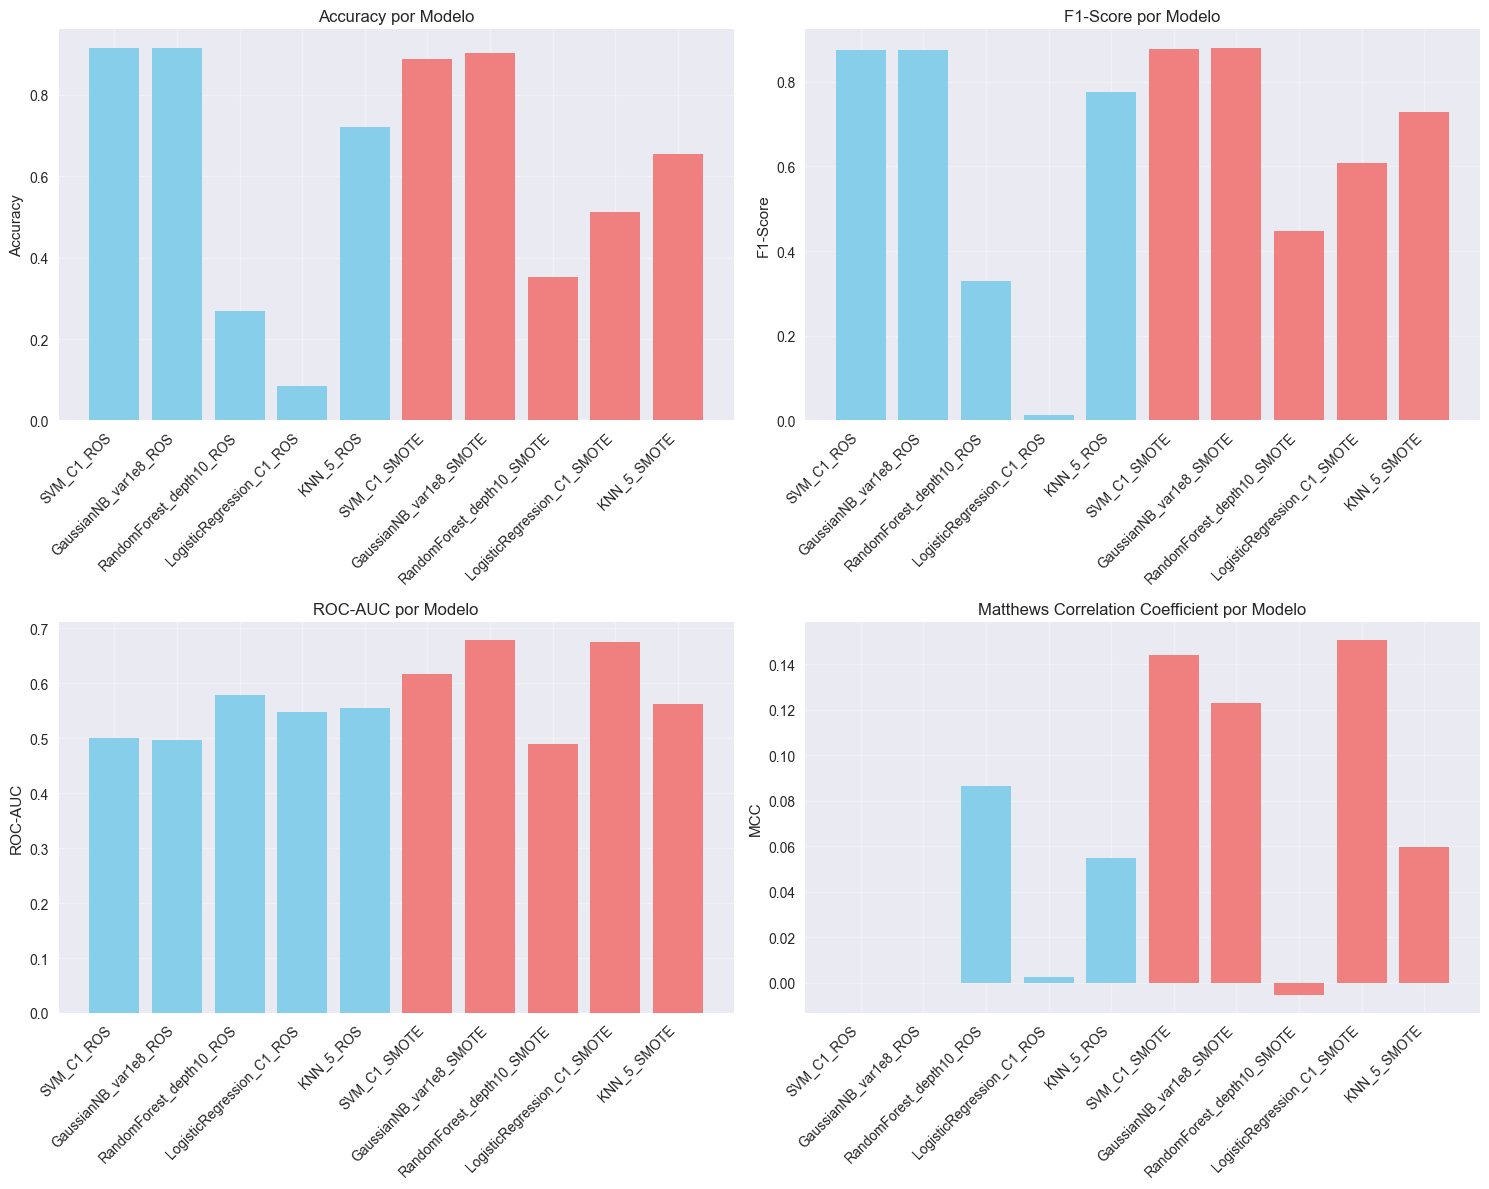

In [15]:
# Combinar todos los resultados
all_results = pd.concat([df_results_ros, df_results_smote], ignore_index=True)

# Crear visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
axes[0,0].bar(range(len(all_results)), all_results['accuracy'], 
              color=['skyblue' if 'ROS' in name else 'lightcoral' for name in all_results['model_name']])
axes[0,0].set_title('Accuracy por Modelo')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_xticks(range(len(all_results)))
axes[0,0].set_xticklabels(all_results['model_name'], rotation=45, ha='right')
axes[0,0].grid(True, alpha=0.3)

# F1-Score
axes[0,1].bar(range(len(all_results)), all_results['f1_score'],
              color=['skyblue' if 'ROS' in name else 'lightcoral' for name in all_results['model_name']])
axes[0,1].set_title('F1-Score por Modelo')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].set_xticks(range(len(all_results)))
axes[0,1].set_xticklabels(all_results['model_name'], rotation=45, ha='right')
axes[0,1].grid(True, alpha=0.3)

# ROC-AUC
roc_auc_values = all_results['roc_auc'].fillna(0)
axes[1,0].bar(range(len(all_results)), roc_auc_values,
              color=['skyblue' if 'ROS' in name else 'lightcoral' for name in all_results['model_name']])
axes[1,0].set_title('ROC-AUC por Modelo')
axes[1,0].set_ylabel('ROC-AUC')
axes[1,0].set_xticks(range(len(all_results)))
axes[1,0].set_xticklabels(all_results['model_name'], rotation=45, ha='right')
axes[1,0].grid(True, alpha=0.3)

# Matthews Correlation Coefficient
axes[1,1].bar(range(len(all_results)), all_results['matthews_corrcoef'],
              color=['skyblue' if 'ROS' in name else 'lightcoral' for name in all_results['model_name']])
axes[1,1].set_title('Matthews Correlation Coefficient por Modelo')
axes[1,1].set_ylabel('MCC')
axes[1,1].set_xticks(range(len(all_results)))
axes[1,1].set_xticklabels(all_results['model_name'], rotation=45, ha='right')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Crear leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='skyblue', label='Random Over Sampling'),
                   Patch(facecolor='lightcoral', label='SMOTE + Tomek')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)


### 6.2 Tabla Resumen de Mejores Modelos


In [16]:
# Identificar mejores modelos por métrica
best_models = {}

metrics_to_analyze = ['accuracy', 'f1_score', 'roc_auc', 'matthews_corrcoef']

for metric in metrics_to_analyze:
    if metric == 'roc_auc':
        # Para ROC-AUC, excluir valores NaN
        valid_results = all_results.dropna(subset=[metric])
        if not valid_results.empty:
            best_idx = valid_results[metric].idxmax()
            best_models[metric] = valid_results.loc[best_idx]
    else:
        best_idx = all_results[metric].idxmax()
        best_models[metric] = all_results.loc[best_idx]

# Crear tabla resumen
print("=== MEJORES MODELOS POR MÉTRICA ===")
print()

for metric, best_model in best_models.items():
    print(f"Mejor {metric.upper()}:")
    print(f"  Modelo: {best_model['model_name']}")
    print(f"  Valor: {best_model[metric]:.4f}")
    print()

# Crear tabla completa ordenada por F1-Score
print("=== RANKING COMPLETO POR F1-SCORE ===")
ranking_table = all_results.sort_values('f1_score', ascending=False)
ranking_table_display = ranking_table[['model_name', 'accuracy', 'precision', 'recall', 
                                      'f1_score', 'roc_auc', 'matthews_corrcoef']].round(4)

print(ranking_table_display.to_string(index=False))


=== MEJORES MODELOS POR MÉTRICA ===

Mejor ACCURACY:
  Modelo: SVM_C1_ROS
  Valor: 0.9147

Mejor F1_SCORE:
  Modelo: GaussianNB_var1e8_SMOTE
  Valor: 0.8793

Mejor ROC_AUC:
  Modelo: GaussianNB_var1e8_SMOTE
  Valor: 0.6776

Mejor MATTHEWS_CORRCOEF:
  Modelo: LogisticRegression_C1_SMOTE
  Valor: 0.1509

=== RANKING COMPLETO POR F1-SCORE ===
                 model_name  accuracy  precision  recall  f1_score  roc_auc  matthews_corrcoef
    GaussianNB_var1e8_SMOTE    0.9015     0.8661  0.9015    0.8793   0.6776             0.1229
               SVM_C1_SMOTE    0.8881     0.8671  0.8881    0.8765   0.6172             0.1442
      GaussianNB_var1e8_ROS    0.9147     0.8367  0.9147    0.8739   0.4960             0.0000
                 SVM_C1_ROS    0.9147     0.8367  0.9147    0.8739   0.5003             0.0000
                  KNN_5_ROS    0.7210     0.8543  0.7210    0.7757   0.5542             0.0551
                KNN_5_SMOTE    0.6537     0.8568  0.6537    0.7292   0.5612             

## 7. Conclusiones y Recomendaciones

### 7.1 Resumen de Técnicas Implementadas



#### 1. MÉTODOS DE INTERPOLACIÓN ADICIONALES:
- **Interpolación Spline Cúbica**: Utiliza polinomios de tercer grado para crear curvas suaves que pasan por todos los puntos de datos.
- **Interpolación por Promedio Móvil**: Usa la media de una ventana deslizante para estimar valores faltantes.

#### 2. TÉCNICAS DE DETECCIÓN DE OUTLIERS ADICIONALES:
- **Método IQR (Rango Intercuartílico)**: Identifica outliers fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR] y los reemplaza con límites.
- **Isolation Forest**: Algoritmo de detección de anomalías que aísla outliers construyendo árboles de decisión aleatorios.

#### 3. TÉCNICAS DE BALANCEO ADICIONALES:
- **Random Over Sampling**: Duplica aleatoriamente muestras de la clase minoritaria.
- **SMOTE + Tomek Links**: Combina SMOTE para generar muestras sintéticas con Tomek Links para limpiar fronteras entre clases.

#### 4. EXTRACCIÓN DE CARACTERÍSTICAS CON IA:
- **Random Forest Feature Extraction**: Utiliza Random Forest para identificar características importantes y crear nuevas características basadas en importancia.
- **Características generadas**: RF_Weighted_Sum, RF_Anomaly_Score, RF_Top3_Combined

#### 5. MODELOS CON HIPERPARÁMETROS ESPECÍFICOS:
- SVM con C=1
- Gaussian Naive Bayes con var_smoothing=1e-8
- Random Forest con max_depth=10
- Logistic Regression con C=1
- K-Nearest Neighbors con k=5

#### 6. COMBINACIONES DE TÉCNICAS EVALUADAS:
- Spline Cúbica + IQR + Random Over Sampling
- Promedio Móvil + Isolation Forest + SMOTE + Tomek


### 7.2 Análisis de Resultados y Recomendaciones


In [17]:

# Análisis basado en los mejores modelos identificados
if 'best_models' in locals():
    print("HALLAZGOS PRINCIPALES:")
    print()
    
    print("1. RENDIMIENTO DE TÉCNICAS DE BALANCEO:")
    ros_models = [model for model in all_results['model_name'] if 'ROS' in model]
    smote_models = [model for model in all_results['model_name'] if 'SMOTE' in model]
    
    ros_avg_f1 = all_results[all_results['model_name'].isin(ros_models)]['f1_score'].mean()
    smote_avg_f1 = all_results[all_results['model_name'].isin(smote_models)]['f1_score'].mean()
    
    print(f"   • Random Over Sampling - F1 promedio: {ros_avg_f1:.4f}")
    print(f"   • SMOTE + Tomek - F1 promedio: {smote_avg_f1:.4f}")
    
    if ros_avg_f1 > smote_avg_f1:
        print("   → Random Over Sampling mostró mejor rendimiento promedio")
    else:
        print("   → SMOTE + Tomek mostró mejor rendimiento promedio")
    print()
    
    print("2. RENDIMIENTO DE MODELOS:")
    model_performance = {}
    for _, row in all_results.iterrows():
        base_model = row['model_name'].split('_')[0] + '_' + row['model_name'].split('_')[1]
        if base_model not in model_performance:
            model_performance[base_model] = []
        model_performance[base_model].append(row['f1_score'])
    
    for model, scores in model_performance.items():
        avg_score = np.mean(scores)
        print(f"   • {model}: F1 promedio = {avg_score:.4f}")
    print()




HALLAZGOS PRINCIPALES:

1. RENDIMIENTO DE TÉCNICAS DE BALANCEO:
   • Random Over Sampling - F1 promedio: 0.5734
   • SMOTE + Tomek - F1 promedio: 0.7084
   → SMOTE + Tomek mostró mejor rendimiento promedio

2. RENDIMIENTO DE MODELOS:
   • SVM_C1: F1 promedio = 0.8752
   • GaussianNB_var1e8: F1 promedio = 0.8766
   • RandomForest_depth10: F1 promedio = 0.3891
   • LogisticRegression_C1: F1 promedio = 0.3111
   • KNN_5: F1 promedio = 0.7524

